# Analyze sample splitting data

In [30]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent
SRC = ROOT / "src"
sys.path.insert(0, str(SRC))

import time
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd
import seaborn as sns
from helpers.sample import make_sample, stopping_time

In [31]:
# load data
summary_results = pd.read_csv(ROOT / "data" / "sample_split_z.csv")

In [33]:
summary_results
subset = summary_results[summary_results["alpha"] == 0.05]
subset

,theta,N,alpha,lambda,psi,mean_theta_hat,sd_theta_hat,mean_z_hat,sd_z_hat,mean_b_hat,sd_b_hat,power,sd_outer_power,mean_seq_stopping_time,mean_total_stopping_time,mean_total_stopping_fraction,early_stop_prob,n_outer_success,n_inner_success
0,0.1,1000,0.05,0.5,0.10,0.135554,0.080872,1.587867,3.180729,0.596084,0.469561,0.549267,0.418824,460.064350,560.064350,0.560064,0.935414,423,21150
1,0.1,1000,0.05,0.5,0.25,0.110204,0.055611,-0.274535,2.598411,0.394704,0.474656,0.362447,0.387436,257.192363,507.192363,0.507192,0.933376,474,23700
2,0.1,1000,0.05,0.5,0.50,0.104370,0.043462,-3.196437,1.973089,0.096941,0.290412,0.108952,0.191071,44.828629,544.828629,0.544829,0.967298,496,24800
3,0.1,1000,0.05,0.5,0.75,0.098670,0.036385,-6.324982,1.726380,0.000369,0.003048,0.050341,0.031286,1.016032,751.016032,0.751016,1.000000,499,24950
4,0.1,1000,0.05,0.5,0.90,0.098452,0.033798,-10.505497,3.041864,0.000040,0.000530,0.051383,0.031077,1.000000,901.000000,0.901000,1.000000,499,24950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2.0,50000,0.05,0.5,0.10,1.999871,0.014283,422.591805,3.029841,0.999990,0.000000,1.000000,0.000000,624.304120,5624.304120,0.112486,1.000000,500,25000
96,2.0,50000,0.05,0.5,0.25,1.999551,0.009114,385.566565,1.764975,0.999990,0.000000,0.999960,0.000894,569.704680,13069.704680,0.261394,1.000000,500,25000
97,2.0,50000,0.05,0.5,0.50,1.999746,0.006045,314.542822,0.955832,0.999990,0.000000,1.000000,0.000000,464.705880,25464.705880,0.509294,1.000000,500,25000
98,2.0,50000,0.05,0.5,0.75,2.000143,0.005345,221.977884,0.597534,0.999990,0.000000,0.999920,0.001264,327.852600,37827.852600,0.756557,1.000000,500,25000


In [49]:
# check specific scenarios
def check_scenario(theta, psi, lambda_):
    return subset[
        (subset["theta"] == theta)
        & (subset["psi"] == psi)
        # & (subset["N"] == N)
        & (subset["lambda"] == lambda_)
    ]

check_scenario(theta = 0.1, psi = 0.9, lambda_ = 0.5)

,theta,N,alpha,lambda,psi,mean_theta_hat,sd_theta_hat,mean_z_hat,sd_z_hat,mean_b_hat,...,mean_seq_stopping_time,mean_total_stopping_time,mean_total_stopping_fraction,early_stop_prob,n_outer_success,n_inner_success,empirical_utility,standard_power,standard_utility,util_diff
4,0.1,1000,0.05,0.5,0.9,0.098452,0.033798,-10.505497,3.041864,0.00004,...,1.00000,901.00000,0.901000,1.0,499,24950,0.424809,0.935420,3.228991e-02,0.392519
9,0.1,2000,0.05,0.5,0.9,0.101160,0.022787,-14.520418,2.900259,0.00001,...,1.00000,1801.00000,0.900500,1.0,500,25000,0.424050,0.997653,1.173623e-03,0.422876
14,0.1,5000,0.05,0.5,0.9,0.100315,0.014583,-21.832830,2.934675,0.00001,...,1.00000,4501.00000,0.900200,1.0,500,25000,0.425220,1.000000,1.439047e-08,0.425220
19,0.1,10000,0.05,0.5,0.9,0.100103,0.010460,-30.134681,2.976909,0.00001,...,1.00000,9001.00000,0.900100,1.0,500,25000,0.424010,1.000000,0.000000e+00,0.424010
24,0.1,50000,0.05,0.5,0.9,0.099907,0.004726,5.419598,0.334216,0.99999,...,3044.76792,48044.76792,0.960895,1.0,500,25000,-0.019552,1.000000,0.000000e+00,-0.019552


In [50]:
0.5 - 0.5 * 0.935

0.03249999999999997

In [ ]:
0.901*0.5 - 0.5 * 0.55138

0.17431000000000002

## Analyze $\hat b$

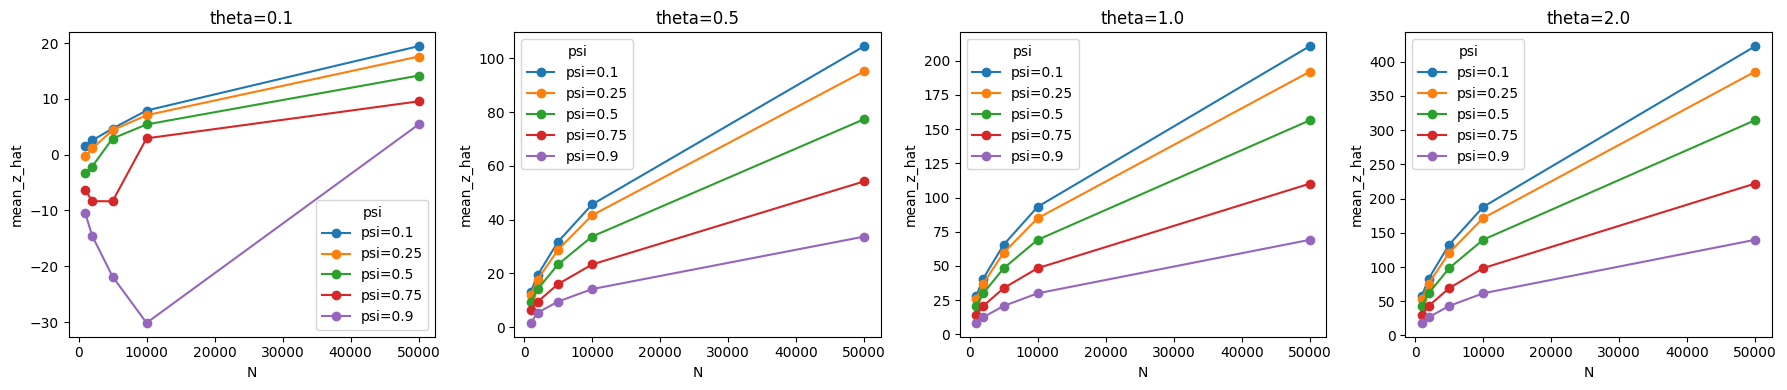

In [55]:
# make a plot of mean_z_hat by theta for different values of psi, N, and lambda
# the plot should have N on the x-axis, mean_z_hat on the y_axis. Different lines should represent \psi. The columns should be different values of lambda and the rows should be different values of theta. Each plot should have a title indicating the value of theta. first subset only alpha = 0.05

psis = sorted(subset["psi"].unique())
thetas = sorted(subset["theta"].unique())
lambdas = sorted(subset["lambda"].unique())

fig, axes = plt.subplots(
    1,
    len(thetas),
    figsize=(4.5 * len(thetas), 4),
    sharex=True,
    sharey=False,
)

# make axes iterable even if len(thetas) == 1
axes = np.atleast_1d(axes)

for i, theta in enumerate(thetas):
    ax = axes[i]

    for psi in psis:
        # if you only have one lambda, use it directly
        lambda_ = lambdas[0]

        data = check_scenario(theta, psi, lambda_)
        ax.plot(
            data["N"],
            data["mean_z_hat"],
            marker="o",
            label=f"psi={psi}",
        )

    ax.set_title(f"theta={theta}")
    ax.set_xlabel("N")
    ax.set_ylabel("mean_z_hat")
    ax.legend(title="psi")

plt.tight_layout()
plt.show()


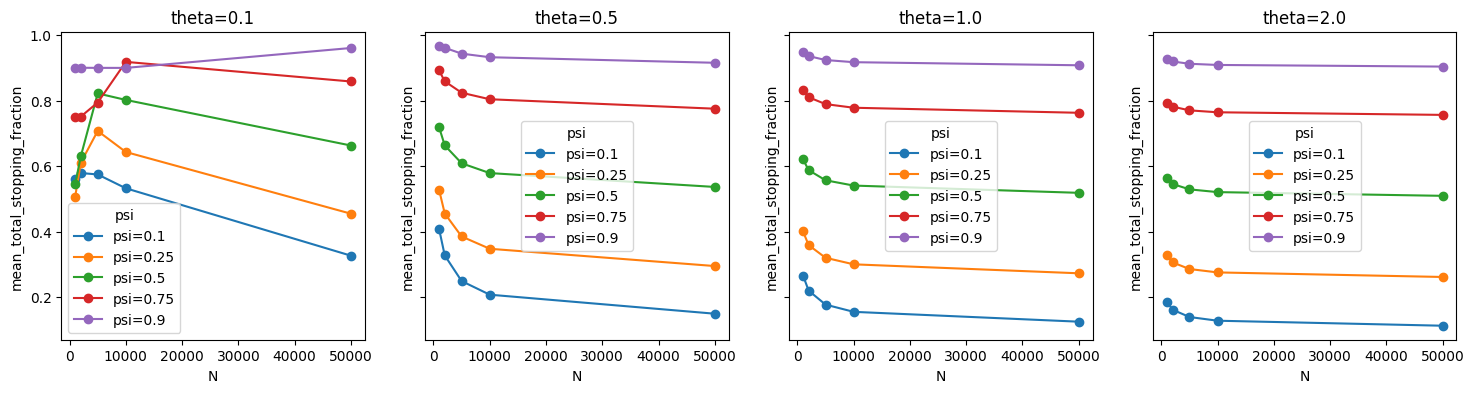

In [39]:
psis = sorted(subset["psi"].unique())
thetas = sorted(subset["theta"].unique())
lambdas = sorted(subset["lambda"].unique())

fig, axes = plt.subplots(
    1,
    len(thetas),
    figsize=(4.5 * len(thetas), 4),
    sharex=True,
    sharey=True,
)

# make axes iterable even if len(thetas) == 1
axes = np.atleast_1d(axes)

for i, theta in enumerate(thetas):
    ax = axes[i]

    for psi in psis:
        # if you only have one lambda, use it directly
        lambda_ = lambdas[0]

        data = check_scenario(theta, psi, lambda_)
        ax.plot(
            data["N"],
            data["mean_total_stopping_fraction"],
            marker="o",
            label=f"psi={psi}",
        )

    ax.set_title(f"theta={theta}")
    ax.set_xlabel("N")
    ax.set_ylabel("mean_total_stopping_fraction")
    ax.legend(title="psi")
plt.show()


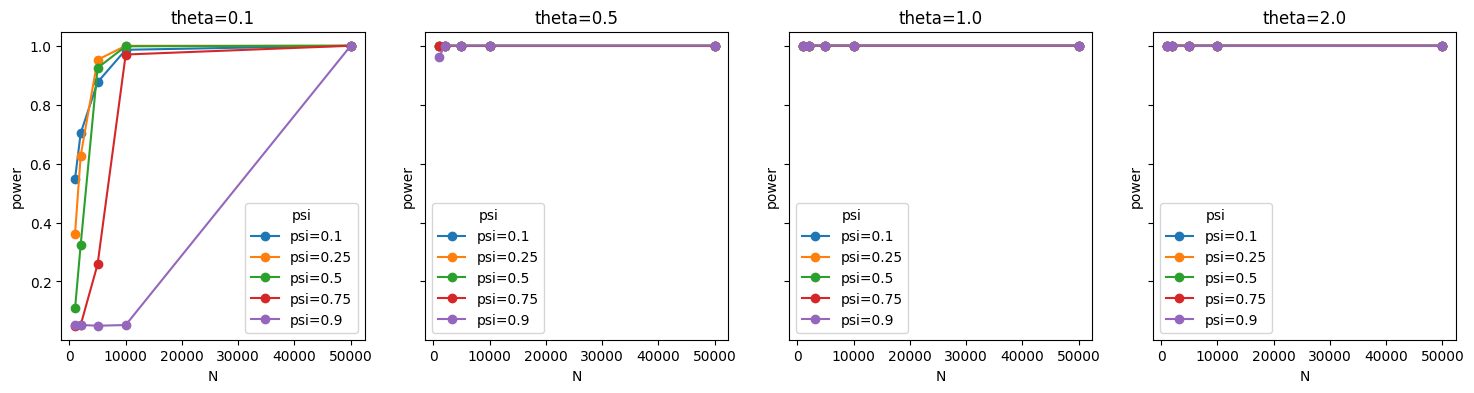

In [42]:
psis = sorted(subset["psi"].unique())
thetas = sorted(subset["theta"].unique())
lambdas = sorted(subset["lambda"].unique())

fig, axes = plt.subplots(
    1,
    len(thetas),
    figsize=(4.5 * len(thetas), 4),
    sharex=True,
    sharey=True,
)

# make axes iterable even if len(thetas) == 1
axes = np.atleast_1d(axes)

for i, theta in enumerate(thetas):
    ax = axes[i]

    for psi in psis:
        # if you only have one lambda, use it directly
        lambda_ = lambdas[0]

        data = check_scenario(theta, psi, lambda_)
        ax.plot(
            data["N"],
            data["power"],
            marker="o",
            label=f"psi={psi}",
        )

    ax.set_title(f"theta={theta}")
    ax.set_xlabel("N")
    ax.set_ylabel("power")
    ax.legend(title="psi")
plt.show()


In [47]:
# calculate empirical utility for each scenario and add it to the dataframe
subset["empirical_utility"] = 0.5 * (subset["mean_total_stopping_fraction"] - subset["power"])

# calculate utility of Z test (no sample splitting) for each scenario using phi functions
subset["standard_power"] = 1 - scipy.stats.norm.cdf(scipy.stats.norm.ppf(1 - subset["alpha"]) - np.sqrt(subset["N"]) * subset["theta"])
subset["standard_utility"] = 0.5 * (1 - subset["standard_power"])

subset["util_diff"] = subset["empirical_utility"] - subset["standard_utility"]

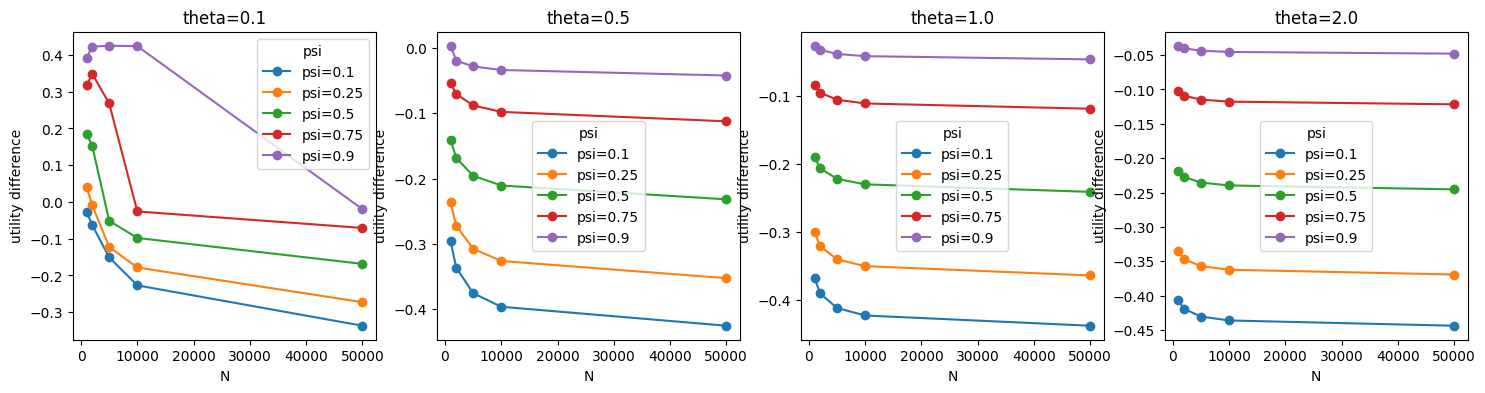

In [48]:
psis = sorted(subset["psi"].unique())
thetas = sorted(subset["theta"].unique())
lambdas = sorted(subset["lambda"].unique())

fig, axes = plt.subplots(
    1,
    len(thetas),
    figsize=(4.5 * len(thetas), 4),
    sharex=True,
    sharey=False
)

# make axes iterable even if len(thetas) == 1
axes = np.atleast_1d(axes)

for i, theta in enumerate(thetas):
    ax = axes[i]

    for psi in psis:
        # if you only have one lambda, use it directly
        lambda_ = lambdas[0]

        data = check_scenario(theta, psi, lambda_)
        ax.plot(
            data["N"],
            data["util_diff"],
            marker="o",
            label=f"psi={psi}",
        )

    ax.set_title(f"theta={theta}")
    ax.set_xlabel("N")
    ax.set_ylabel("utility difference")
    ax.legend(title="psi")
plt.show()